In [1]:
# For debugging
%load_ext autoreload
%autoreload 2

In [2]:
from copy import deepcopy

import torch
import torch.nn
import torch.optim
from torch.utils.data import DataLoader

import xarray as xr
import numpy

from tqdm.notebook import tqdm 

from neural_net_old import get_net
from constants import *

import matplotlib.pyplot as plt

In [3]:
def plot_q(q, ax=None, title='', cbar=False):
    # Plot a 2D vorticity field. q should be shape (H, W).
    if ax is None:
        fig, ax = plt.subplots()
    q = np.asarray(q).squeeze()          # ensure 2-D
    assert q.ndim == 2, f"Expected 2D array, got shape {q.shape}"
    qmax = np.abs(q).max()
    pc = ax.pcolormesh(
        np.linspace(0, 2*np.pi, q.shape[1] + 1),   # (W+1,) cell edges
        np.linspace(0, 2*np.pi, q.shape[0] + 1),   # (H+1,) cell edges
        q, cmap='seismic', vmin=-qmax, vmax=qmax,
        shading='flat'
    )
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    return pc

In [4]:
torch.manual_seed(42)

# Settings

In [5]:
device = torch.device("cuda")
dtype = torch.bfloat16

batch_size = 1
n_epochs = 1000 
n_layers = 4

# Load data
Training data will have shape (time, 2, dim, dim). On the channels dimension we have concatenated the normalized states and the normalized residuals. 

In [6]:
# Load only first 4 time steps
ds_train = xr.open_zarr("../data/sqg_train.zarr")["q"].isel(time=slice(4,6)).compute()

print("New shape:", ds_train.shape)  # should be (4, nx, ny)

# Normalize data
train_data = torch.cat((
    (torch.as_tensor(ds_train.values[:-1], dtype=dtype) - in_mean) / in_std,
    (torch.as_tensor(ds_train.values[1:] - ds_train.values[:-1], dtype=dtype) - res_mean) / res_std
), dim=1)

print("train mean:", train_data.mean().item())
print("train std :", train_data.std().item())

del ds_train

train_loader = DataLoader(
    train_data,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

print("len train loader:", len(train_loader))

New shape: (2, 1, 512, 512)
train mean: -1.7436686903238297e-06
train std : 1.0977236032485962
len train loader: 1


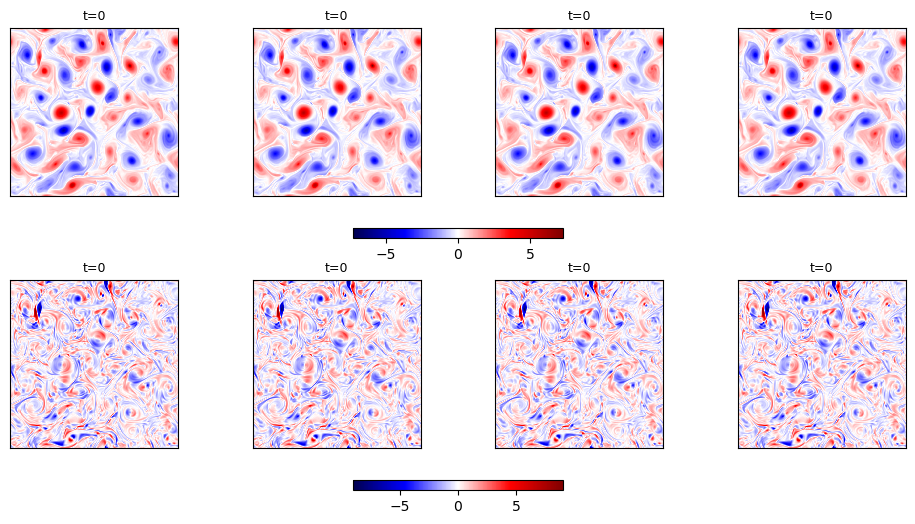

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Assume train_data is shape (time, channels, H, W)
time_len = train_data.shape[0]
channels = train_data.shape[1]
time_indices = np.linspace(0, time_len - 1, 4, dtype=int)
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, t_idx in enumerate(time_indices):
    # First row: channel 0
    ax = axes[0, i]
    pc = plot_q(train_data[t_idx, 0, :, :], ax=ax, title=f"t={t_idx}")
    if i == 3:  # only one colorbar per row for clarity
        fig.colorbar(pc, ax=axes[0, :], orientation='horizontal', fraction=0.05)

    # Second row: channel 1
    ax = axes[1, i]
    pc = plot_q(train_data[t_idx, 1, :, :], ax=ax, title=f"t={t_idx}")
    if i == 3:
        fig.colorbar(pc, ax=axes[1, :], orientation='horizontal', fraction=0.05)

plt.show()

In [51]:
ds_val = xr.open_zarr("../data/sqg_val.zarr")["q"].isel(time=slice(4, 6)).compute() # validation data 
val_data = torch.cat((
    (torch.as_tensor(ds_val.values[:-1], dtype=dtype)-in_mean) / in_std,
    (torch.as_tensor(ds_val.values[1:]-ds_val.values[:-1], dtype=dtype)-res_mean) / res_std
), dim=1)
print(ds_val.time.shape) 

print("val mean:", val_data.mean().item())
print("val std :", val_data.std().item())

del ds_val

val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

(2,)
val mean: 1.3737007975578308e-06
val std : 0.9761533737182617


# Define neural network
ConvNet

In [55]:

n_features = 256
#n_embedding = 32

wave_length = 1.0

lr = 5e-3

model = get_net(
    # Input: intermediate state (1) + initial conditions (1)
    n_input=2,
    n_output=1, n_layers = n_layers,  
    n_features=n_features, mult=2,
    # Activation of pseudo time
    use_time = True, 
    #n_embedding=n_embedding, 
    wave_length=wave_length,
    device=device, dtype=dtype
)
optim = torch.optim.Adam(model.parameters(), lr=lr) # maybe use Adam w? 

In [56]:
import json
import matplotlib.pyplot as plt

train_losses = []
val_losses = []

pbar_epoch = tqdm(range(n_epochs))
mse_val = torch.inf
best_mse = torch.inf
best_model = None

for epoch_idx, _ in enumerate(pbar_epoch):
    pbar_train = tqdm(iter(train_loader), total=len(train_loader), leave=True)
    # Training loop
    model = model.train()
    epoch_train_loss = 0
    epoch_train_samples = 0
    for batch_idx, batch in enumerate(pbar_train):        
        batch = batch.to(device=device, dtype=dtype)
        data_in, data_target = batch.split((1, 1), dim=1)
        print("data in mean and std:", data_in.mean().item(), data_in.std().item()) 
        print("data target mean and std:", data_target.mean().item(), data_target.std().item()) 

        noise = torch.randn_like(data_target)
        #pseudo_time = torch.linspace(0, 1, batch.shape[0]+1, device=device, dtype=dtype)[:-1, None]
        #time_shift = torch.rand(1, device=device, dtype=dtype)
        #pseudo_time = (pseudo_time + time_shift) % 1
        # copilot suggestion
        pseudo_time = torch.full((batch.shape[0], 1), 0.5, device=device, dtype=dtype)

        intermediate_state = pseudo_time[..., None, None] * data_target \
            + (1 - pseudo_time[..., None, None]) * noise
        target_velocity = data_target - noise
        input_tensor = torch.cat((intermediate_state, data_in), dim=1)
        optim.zero_grad()
        
        prediction = model(input_tensor, pseudo_time)
        print("prediction mean and std:", prediction.mean().item(), prediction.std().item())
        print("target velocity mean and std:", target_velocity.mean().item(), target_velocity.std().item())
        error = (prediction - target_velocity).pow(2)
        mse_train = error.mean()
        mse_train.backward()
        optim.step()
        #scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=n_epochs, eta_min=1e-6)
        # at end of each epoch:
        #scheduler.step()

        # Accumulate training loss (same weighted avg logic as val)
        curr_se = error.mean(dim=(1, 2, 3)).sum().item()
        epoch_train_loss = (epoch_train_loss * epoch_train_samples + curr_se) / (epoch_train_samples + len(batch))
        epoch_train_samples += len(batch)

        pbar_train.set_postfix(mse_train=mse_train.item(), mse_val=mse_val)

    train_losses.append(epoch_train_loss)

    mse_val = 0
    samples_val = 0
    pbar_val = tqdm(enumerate(val_loader), total=len(val_loader), leave=False)
    
    # Validation loop
    model = model.eval()
    for k, batch in pbar_val:        
        batch = batch.to(device=device, dtype=dtype)
        
        data_in, data_target = batch.split((1,1), dim=1)
        
        noise = torch.randn_like(data_target)
        #pseudo_time = torch.linspace(0, 1, batch.shape[0]+1, device=device, dtype=dtype)[:-1, None]
        #time_shift = torch.rand(1, device=device, dtype=dtype)
        #pseudo_time = (pseudo_time + time_shift) % 1
        pseudo_time = torch.full((batch.shape[0], 1), 0.5, device=device, dtype=dtype)

        intermediate_state = pseudo_time[..., None, None] * data_target \
            + (1 - pseudo_time[..., None, None]) * noise
        target_velocity = data_target - noise
        input_tensor = torch.cat((intermediate_state, data_in), dim=1)
        
        with torch.no_grad():
            prediction = model(input_tensor, pseudo_time)
        error = (prediction - target_velocity).pow(2)
        curr_se = error.mean(dim=(1, 2, 3)).sum().item()
        mse_val = (mse_val * samples_val + curr_se) / (samples_val + len(batch))
        samples_val += len(batch)

    val_losses.append(mse_val)
    pbar_train.set_postfix(mse_train=mse_train.item(), mse_val=mse_val)
    pbar_epoch.set_postfix(train=epoch_train_loss, val=mse_val)

    # Save losses to JSON
    loss_history = {"train": train_losses, "val": val_losses}
    with open("loss_history.json", "w") as f:
        json.dump(loss_history, f, indent=2)

    # Save loss plot
    fig, ax = plt.subplots(figsize=(8, 5))
    epochs = range(1, epoch_idx + 2)
    ax.plot(epochs, train_losses, label="Train MSE", marker="o", markersize=3)
    ax.plot(epochs, val_losses,   label="Val MSE",   marker="o", markersize=3)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE")
    ax.set_title("Training & Validation Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("loss_history.png", dpi=150)
    plt.close(fig)
        
    if mse_val < 0.999 * best_mse:
        best_mse = mse_val
        best_model = deepcopy(model).cpu()

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

data in mean and std: 1.5720725059509277e-06 1.0625
data target mean and std: -5.364418029785156e-06 1.1328125
prediction mean and std: -0.04541015625 0.034912109375
target velocity mean and std: 0.000148773193359375 1.5078125


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

...

data in mean and std: 1.5720725059509277e-06 1.0625
data target mean and std: -5.364418029785156e-06 1.1328125
prediction mean and std: 0.01171875 1.4140625
target velocity mean and std: 0.0002841949462890625 1.5078125


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

data in mean and std: 1.5720725059509277e-06 1.0625
data target mean and std: -5.364418029785156e-06 1.1328125
prediction mean and std: 0.0264892578125 1.421875
target velocity mean and std: 0.003265380859375 1.515625


  0%|          | 0/1 [00:00<?, ?it/s]

# Store best model

In [57]:
import os 
if best_model is not None:
    # Save best model checkpoint
    ckpt = {
        "model_state_dict": best_model.state_dict(),  # Save best
        "optimizer_state_dict": optim.state_dict(),
        "best_mse": best_mse,  # Track best MSE
        "config": {
            "n_input": 2,  
            "n_output": 1,
            "n_features": n_features,
            "mult": 2,
            "use_time": True,       
            "wave_length": wave_length,
        }
    }
    torch.save(ckpt, os.path.join("..", "data", "best_flowcondmodel_test_convnet.ckpt"))
    print(f"Saved best checkpoint (MSE={best_mse:.6f}) to ../data/best_flowmodel_test.ckpt")
else:
    print("Warning: No model was saved (validation never improved)")

Saved best checkpoint (MSE=0.238281) to ../data/best_flowmodel_test.ckpt
